# 🦆 DuckDB GROUP BY Tutorial
## Teaching Notebook with Visualizations

## Setup

In [1]:

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()


## Create Table and Insert Data

In [ ]:
con.execute("""
CREATE TABLE scores(country VARCHAR, team VARCHAR, score INTEGER);
""")

con.execute("""
INSERT INTO scores VALUES
('USA','RED',10),('USA','RED',20),('USA','RED',30),
('USA','BLUE',20),('USA','BLUE',40),('USA','BLUE',70),
('CANADA','RED',30),('CANADA','RED',60),('CANADA','RED',80),
('CANADA','BLUE',10),('CANADA','BLUE',40),('CANADA','BLUE',90),
('GERMANY','RED',20),('GERMANY','RED',40),
('GERMANY','BLUE',30),('GERMANY','BLUE',70);
""")

---
# View All rows:

In [13]:
con.execute("SELECT * FROM scores").df()

,country,team,score
0,USA,RED,10
1,USA,RED,20
2,USA,RED,30
3,USA,BLUE,20
4,USA,BLUE,40
5,USA,BLUE,70
6,CANADA,RED,30
7,CANADA,RED,60
8,CANADA,RED,80
9,CANADA,BLUE,10


## GROUP BY Country — Total Score

In [14]:

df_country = con.execute("""
SELECT country, SUM(score) AS total_score
FROM scores
GROUP BY country
ORDER BY total_score DESC
""").df()

df_country


,country,total_score
0,CANADA,310.0
1,USA,190.0
2,GERMANY,160.0


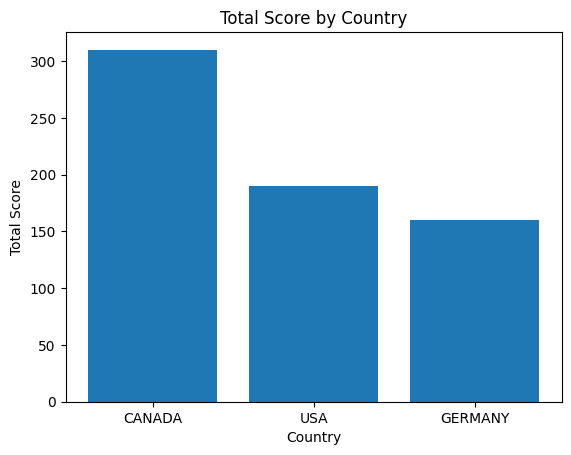

In [4]:

plt.figure()
plt.bar(df_country['country'], df_country['total_score'])
plt.title("Total Score by Country")
plt.xlabel("Country")
plt.ylabel("Total Score")
plt.show()


## GROUP BY Team — Total Score

In [5]:

df_team = con.execute("""
SELECT team, SUM(score) AS total_score
FROM scores
GROUP BY team
""").df()

df_team


,team,total_score
0,BLUE,370.0
1,RED,290.0


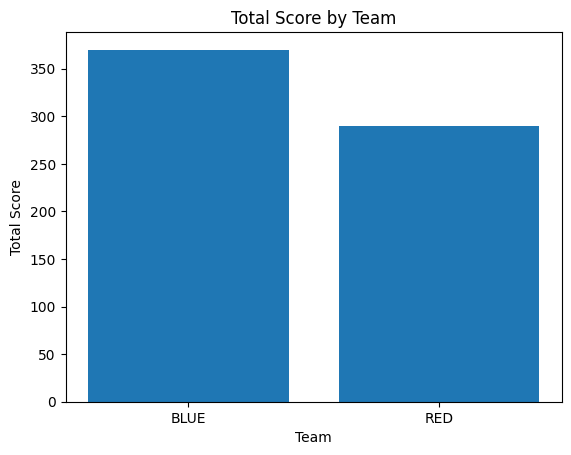

In [6]:

plt.figure()
plt.bar(df_team['team'], df_team['total_score'])
plt.title("Total Score by Team")
plt.xlabel("Team")
plt.ylabel("Total Score")
plt.show()


## GROUP BY Country + Team

In [7]:

df_ct = con.execute("""
SELECT country, team, SUM(score) AS total_score
FROM scores
GROUP BY country, team
ORDER BY country, team
""").df()

df_ct


,country,team,total_score
0,CANADA,BLUE,140.0
1,CANADA,RED,170.0
2,GERMANY,BLUE,100.0
3,GERMANY,RED,60.0
4,USA,BLUE,130.0
5,USA,RED,60.0


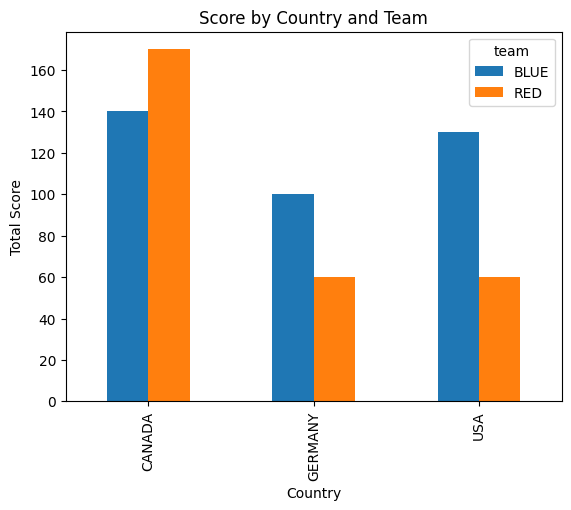

In [8]:

pivot = df_ct.pivot(index='country', columns='team', values='total_score')

pivot.plot(kind='bar')
plt.title("Score by Country and Team")
plt.xlabel("Country")
plt.ylabel("Total Score")
plt.show()


## GROUP BY Country — Average Score

In [9]:

df_avg = con.execute("""
SELECT country, AVG(score) AS avg_score
FROM scores
GROUP BY country
""").df()

df_avg


,country,avg_score
0,USA,31.666667
1,GERMANY,40.000000
2,CANADA,51.666667


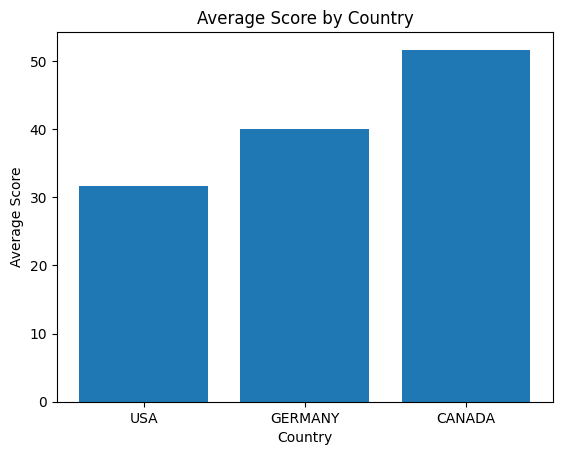

In [10]:

plt.figure()
plt.bar(df_avg['country'], df_avg['avg_score'])
plt.title("Average Score by Country")
plt.xlabel("Country")
plt.ylabel("Average Score")
plt.show()


## GROUP BY Country — Count of Records

In [11]:

df_count = con.execute("""
SELECT country, COUNT(*) AS cnt
FROM scores
GROUP BY country
""").df()

df_count


,country,cnt
0,USA,6
1,GERMANY,4
2,CANADA,6


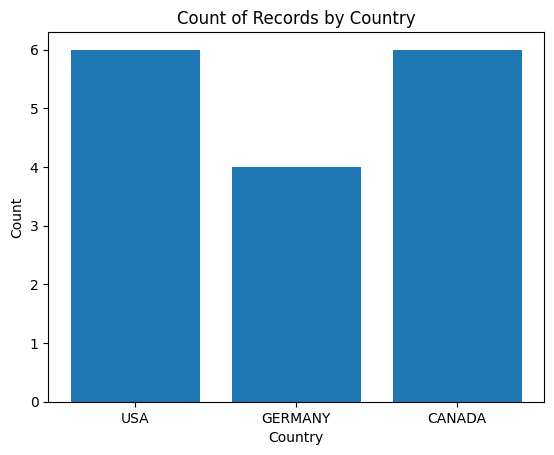

In [12]:

plt.figure()
plt.bar(df_count['country'], df_count['cnt'])
plt.title("Count of Records by Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()
